# Oncology Clinical Trials Landscape

### Exploring the global oncology drug development pipeline using ClinicalTrials.gov data

**Author:** Maria Luz Acevedo  
**Tools:** Python, Pandas, Matplotlib, Seaborn, ClinicalTrials.gov API

<h1 style="color:steelblue;">1. Introduction</h1>

Cancer remains one of the leading causes of mortality worldwide and continues to drive extensive pharmaceutical research and clinical innovation. Thousands of clinical trials are conducted every year to evaluate novel therapeutic strategies, optimize existing treatments, and improve patient outcomes across a wide range of malignancies.

Public repositories such as ClinicalTrials.gov provide valuable access to information on ongoing and completed clinical studies, making it possible to explore trends in oncology drug development through data analysis.

In this project, data were retrieved directly from the ClinicalTrials.gov API and analyzed using Python. The objective is to characterize the current oncology clinical trial landscape by examining study phases, temporal trends, sponsors, cancer types, therapeutic agents, and treatment strategies.

<h1 style="color:steelblue;">2. Objectives</h1>

The main objectives of this project are:

- Analyze the distribution of oncology clinical trials across clinical phases.
- Explore temporal trends in oncology drug development.
- Identify the leading organizations sponsoring oncology studies.
- Characterize the most frequently investigated cancer types.
- Investigate the therapeutic agents most commonly evaluated in oncology.
- Explore therapeutic strategies across different cancer types.

<h1 style="color:steelblue;">3. Data Collection</h1>

The dataset was obtained directly from the ClinicalTrials.gov REST API, one of the largest publicly available repositories of clinical trial information.

A custom Python function was developed to query the API, retrieve oncology-related studies using keyword-based searches, and automatically download the results through pagination.

For this exploratory analysis, a maximum of 3,000 studies were retrieved to ensure a representative sample while maintaining efficient processing.

In [215]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

import os

os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

In [210]:
def download_all_studies(search_term, page_size=100, max_studies=5000):
    url = "https://clinicaltrials.gov/api/v2/studies"

    all_studies = []
    next_page_token = None

    while len(all_studies) < max_studies:

        params = {
            "query.cond": search_term,
            "filter.overallStatus": "RECRUITING|ACTIVE_NOT_RECRUITING|COMPLETED",
            "filter.advanced": "AREA[StudyType]INTERVENTIONAL",
            "pageSize": page_size,
            "format": "json"
        }

        if next_page_token:
            params["pageToken"] = next_page_token

        response = requests.get(url, params=params)
        response.raise_for_status()

        data = response.json()

        studies = data.get("studies", [])
        all_studies.extend(studies)

        print(f"Downloaded {len(all_studies)} studies...")

        next_page_token = data.get("nextPageToken")

        if not next_page_token:
            break

    return all_studies[:max_studies]

In [196]:
all_studies = download_all_studies(
    search_term="cancer",
    max_studies=3000
)
len(all_studies)

Downloaded 100 studies...
Downloaded 200 studies...
Downloaded 300 studies...
Downloaded 400 studies...
Downloaded 500 studies...
Downloaded 600 studies...
Downloaded 700 studies...
Downloaded 800 studies...
Downloaded 900 studies...
Downloaded 1000 studies...
Downloaded 1100 studies...
Downloaded 1200 studies...
Downloaded 1300 studies...
Downloaded 1400 studies...
Downloaded 1500 studies...
Downloaded 1600 studies...
Downloaded 1700 studies...
Downloaded 1800 studies...
Downloaded 1900 studies...
Downloaded 2000 studies...
Downloaded 2100 studies...
Downloaded 2200 studies...
Downloaded 2300 studies...
Downloaded 2400 studies...
Downloaded 2500 studies...
Downloaded 2600 studies...
Downloaded 2700 studies...
Downloaded 2800 studies...
Downloaded 2900 studies...
Downloaded 3000 studies...


3000

<h2 style="color:#6BAED6;">3.1 Data Extraction</h2>

Each clinical study contains multiple nested information modules. To facilitate downstream analysis, the relevant variables were extracted and organized into a structured Pandas DataFrame.

The following variables were retained:

- Clinical trial identifier (NCT ID)
- Study title
- Clinical phase
- Recruitment status
- Study start date
- Lead sponsor
- Sponsor category
- Cancer condition
- Therapeutic intervention
- Intervention type
- Estimated enrollment

In [197]:
def extract_study_info(study):

    protocol = study.get("protocolSection", {})

    identification = protocol.get("identificationModule", {})
    status = protocol.get("statusModule", {})
    sponsor = protocol.get("sponsorCollaboratorsModule", {})
    design = protocol.get("designModule", {})
    conditions = protocol.get("conditionsModule", {})
    interventions = protocol.get("armsInterventionsModule", {})

    return {
        "nct_id": identification.get("nctId"),

        "title": identification.get("briefTitle"),

        "phase": ", ".join(design.get("phases", [])),

        "status": status.get("overallStatus"),

        "start_date": status.get("startDateStruct", {}).get("date"),

        "sponsor": sponsor.get("leadSponsor", {}).get("name"),

        "sponsor_type": sponsor.get("leadSponsor", {}).get("class"),

        "condition": ", ".join(conditions.get("conditions", [])),

        "intervention": ", ".join(
            [i.get("name") for i in interventions.get("interventions", [])
            if i.get("name") is not None
            ]
        ),

        "intervention_type": ", ".join(
            [i.get("type") for i in interventions.get("interventions", [])
            if i.get("type") is not None
            ]
        ),

        "enrollment": design.get("enrollmentInfo", {}).get("count")
    }

In [198]:
records = []

for study in all_studies:
    records.append(extract_study_info(study))

In [199]:
df = pd.DataFrame(records)

In [200]:
df.head()

,nct_id,title,phase,status,start_date,sponsor,sponsor_type,condition,intervention,intervention_type,enrollment
0,NCT06045975,Durvalumab/Tremelimumab in Neoadjuvant and Adj...,PHASE2,ACTIVE_NOT_RECRUITING,2024-03-28,Assistance Publique - Hôpitaux de Paris,OTHER,HCC - Hepatocellular Carcinoma,Durvalumab/Tremelimumab in neoadjuvant and Dur...,DRUG,30.0
1,NCT00193375,"Irinotecan, Carboplatin and Radiation Therapy ...",PHASE2,COMPLETED,2003-08,"SCRI Development Innovations, LLC",OTHER,Lung Cancer,"Irinotecan, Carboplatin, Bevacizumab, Radiation","DRUG, DRUG, DRUG, RADIATION",60.0
2,NCT04696575,Lamivudine in Combination With Chemoimmunother...,PHASE2,RECRUITING,2021-07-02,Roswell Park Cancer Institute,OTHER,Extensive Stage Lung Small Cell Carcinoma,"Atezolizumab, Carboplatin, Etoposide, Lamivudine","BIOLOGICAL, DRUG, DRUG, DRUG",28.0
3,NCT00873457,Perifosine in Relapsed or Refractory Chronic L...,PHASE2,COMPLETED,2009-08,Daphne Friedman,OTHER,"Chronic Lymphocytic Leukemia, Small Lymphocyti...",perifosine,DRUG,16.0
4,NCT02415881,Panitumumab IRDye800 Optical Imaging Study,PHASE1,COMPLETED,2016-08,Eben Rosenthal,OTHER,Head and Neck Cancer,"Panitumumab IRDye 800, da Vinci Firefly, IMAGE...","DRUG, DEVICE, DEVICE",64.0


In [201]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nct_id             3000 non-null   str    
 1   title              3000 non-null   str    
 2   phase              3000 non-null   str    
 3   status             3000 non-null   str    
 4   start_date         2991 non-null   str    
 5   sponsor            3000 non-null   str    
 6   sponsor_type       3000 non-null   str    
 7   condition          3000 non-null   str    
 8   intervention       3000 non-null   str    
 9   intervention_type  3000 non-null   str    
 10  enrollment         2937 non-null   float64
dtypes: float64(1), str(10)
memory usage: 257.9 KB


<h2 style="color:#6BAED6;">3.2 Data Cleaning</h2>

The raw ClinicalTrials.gov data were inspected and processed to create a structured dataset focused on oncology drug development.

Cleaning steps included:
- Handling missing values
- Identifying drug-based interventions
- Removing duplicated studies
- Standardizing clinical phase categories

In [203]:
df_clean = df.copy()

In [202]:
# Convert dates
df_clean["start_date"] = pd.to_datetime(
    df_clean["start_date"],
    errors="coerce" 
)

In [204]:
# Standardize phases
df_clean["phase"] = df_clean["phase"].replace(
    ["NA", ""],
    "NOT_REPORTED"
)

In [205]:
# Keep only drug studies
df_clean["has_drug"] = df_clean["intervention_type"].str.contains(
    "DRUG"
)

In [206]:
df_clean.head()

,nct_id,title,phase,status,start_date,sponsor,sponsor_type,condition,intervention,intervention_type,enrollment,has_drug
0,NCT06045975,Durvalumab/Tremelimumab in Neoadjuvant and Adj...,PHASE2,ACTIVE_NOT_RECRUITING,2024-03-28,Assistance Publique - Hôpitaux de Paris,OTHER,HCC - Hepatocellular Carcinoma,Durvalumab/Tremelimumab in neoadjuvant and Dur...,DRUG,30.0,True
1,NCT00193375,"Irinotecan, Carboplatin and Radiation Therapy ...",PHASE2,COMPLETED,2003-08,"SCRI Development Innovations, LLC",OTHER,Lung Cancer,"Irinotecan, Carboplatin, Bevacizumab, Radiation","DRUG, DRUG, DRUG, RADIATION",60.0,True
2,NCT04696575,Lamivudine in Combination With Chemoimmunother...,PHASE2,RECRUITING,2021-07-02,Roswell Park Cancer Institute,OTHER,Extensive Stage Lung Small Cell Carcinoma,"Atezolizumab, Carboplatin, Etoposide, Lamivudine","BIOLOGICAL, DRUG, DRUG, DRUG",28.0,True
3,NCT00873457,Perifosine in Relapsed or Refractory Chronic L...,PHASE2,COMPLETED,2009-08,Daphne Friedman,OTHER,"Chronic Lymphocytic Leukemia, Small Lymphocyti...",perifosine,DRUG,16.0,True
4,NCT02415881,Panitumumab IRDye800 Optical Imaging Study,PHASE1,COMPLETED,2016-08,Eben Rosenthal,OTHER,Head and Neck Cancer,"Panitumumab IRDye 800, da Vinci Firefly, IMAGE...","DRUG, DEVICE, DEVICE",64.0,True


In [131]:
df_clean["has_drug"].value_counts()

has_drug
True     1918
False    1082
Name: count, dtype: int64

In [132]:
df_clean.shape

(3000, 12)

In [133]:
df_drugs = df_clean[df_clean["has_drug"] == True].copy()

In [134]:
df_drugs.shape

(1918, 12)

In [135]:
df_drugs["nct_id"].duplicated().sum()

np.int64(0)

In [211]:
# Standardize phases
df_drugs["main_phase"] = df_drugs["phase"].str.extract(r"(PHASE\d|EARLY_PHASE1)")

df_drugs["main_phase"].value_counts()

main_phase
PHASE2          838
PHASE1          645
PHASE3          248
PHASE4           59
EARLY_PHASE1     34
Name: count, dtype: int64

<h1 style="color:steelblue;">4. Exploratory Data Analysis (EDA)</h1>

After cleaning and preprocessing the dataset, exploratory data analysis was performed to identify patterns and trends in oncology drug development.

The analysis focused on:
- Distribution of clinical development phases
- Temporal trends in oncology clinical trials
- Leading sponsors and organizations
- Therapeutic interventions and drug development patterns

<h2 style="color:#6BAED6;">4.1 Clinical Phase Distribution</h2>

Clinical trials are conducted through sequential phases that evaluate different aspects of a therapeutic candidate.

- Phase I: evaluates safety, tolerability and dose range, usually in a small number of participants.
- Phase II: evaluates preliminary efficacy and continues safety assessment in patients with the target disease.
- Phase III: confirms efficacy and safety in larger populations and provides evidence for regulatory approval.
- Phase IV: evaluates post-marketing safety and effectiveness after approval.

Analyzing the distribution of clinical phases provides insight into the maturity and composition of the oncology drug development pipeline.

In [138]:
phase_counts = df_drugs["main_phase"].value_counts().reset_index()

phase_counts.columns = ["Phase", "Number of Studies"]

phase_counts

,Phase,Number of Studies
0,PHASE2,846
1,PHASE1,652
2,PHASE3,253
3,PHASE4,60
4,EARLY_PHASE1,34


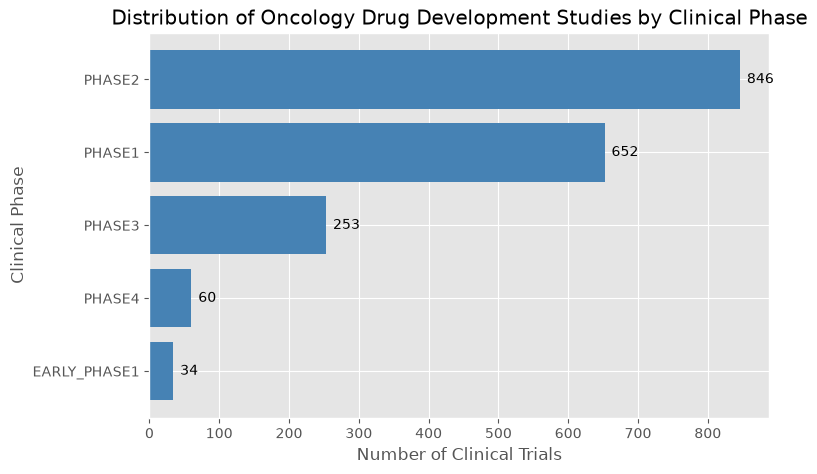

In [219]:
plt.figure(figsize=(8,5))

plt.barh(
    phase_counts["Phase"],
    phase_counts["Number of Studies"],
    color="steelblue"
)

for index, value in enumerate(phase_counts["Number of Studies"]):
    plt.text(
        value + 10,
        index,
        str(value),
        va="center"
    )

plt.xlabel("Number of Clinical Trials")
plt.ylabel("Clinical Phase")
plt.title("Distribution of Oncology Drug Development Studies by Clinical Phase")

plt.gca().invert_yaxis()
plt.savefig("../figures/clinical_phase_distribution.png", dpi=300)

plt.show()

### Interpretation

The oncology drug development landscape is dominated by early and intermediate clinical development stages.

Phase II studies represent the largest proportion of trials, followed by Phase I studies. This pattern suggests a highly active pipeline where many therapeutic candidates have progressed beyond initial safety evaluation but have not yet reached late-stage confirmatory trials.

The relatively lower number of Phase III studies reflects the progressive attrition that occurs during clinical development, where only a fraction of candidates successfully advance toward regulatory evaluation.

<h2 style="color:#6BAED6;">4.2 Temporal Trends in Oncology Drug Development</h2>

Clinical development activity changes over time as new therapeutic strategies emerge and research priorities evolve.

Analyzing the temporal distribution of oncology clinical trials allows us to identify periods of increased research activity and understand how the oncology drug development landscape has changed in recent years.

In [228]:
df_clean["start_date"] = pd.to_datetime(
    df_clean["start_date"],
    errors="coerce"
)

In [229]:
df_drugs["start_year"] = df_drugs["start_date"].dt.year

In [231]:
year_counts = (
    df_drugs["start_year"]
    .value_counts()
    .sort_index()
)

year_counts

start_year
1993.0      1
1995.0      1
1996.0      1
1997.0      1
1998.0      4
1999.0      2
2000.0      3
2001.0      2
2002.0      2
2003.0      2
2004.0      4
2005.0      7
2006.0      7
2007.0      6
2008.0     16
2009.0     17
2010.0     14
2011.0     15
2012.0     27
2013.0     29
2014.0     39
2015.0     47
2016.0     42
2017.0     67
2018.0     68
2019.0     81
2020.0     81
2021.0    109
2022.0     86
2023.0     85
2024.0    114
2025.0    102
2026.0     46
Name: count, dtype: int64

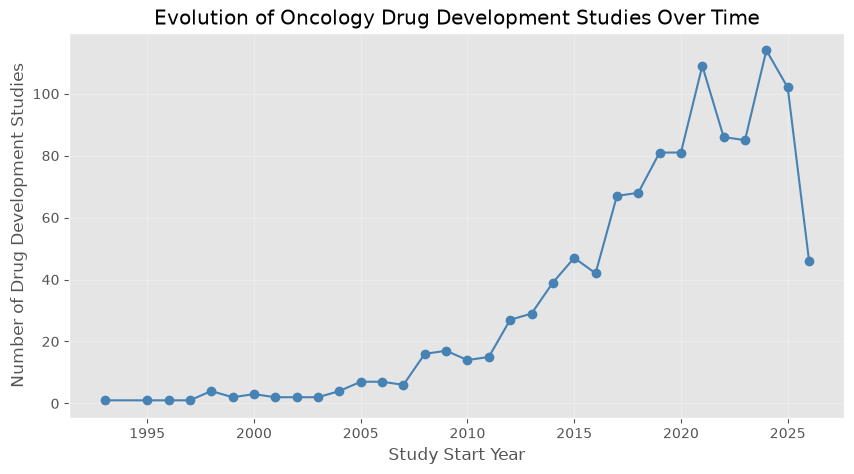

In [234]:
plt.figure(figsize=(10,5))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    color="steelblue"
)

plt.xlabel("Study Start Year")
plt.ylabel("Number of Drug Development Studies")

plt.title(
    "Evolution of Oncology Drug Development Studies Over Time"
)

plt.grid(alpha=0.3)
plt.savefig("../figures/temporal_trends.png", dpi=300)
plt.show()

### Interpretation

The number of oncology drug development studies has increased over the last decades, with a marked expansion after 2010.

The growth observed in recent years reflects increased clinical activity in oncology, likely driven by the development of targeted therapies, immunotherapies and other precision medicine approaches.

The lower number of studies in 2026 should be interpreted cautiously, as the dataset only captures studies registered up to the current date.

<h2 style="color:#6BAED6;">4.3 Leading Sponsors in Oncology Drug Development</h2>

Clinical trials are sponsored by different types of organizations, including pharmaceutical companies, academic institutions, hospitals and research networks.

Analyzing sponsor distribution provides insight into the main contributors driving oncology drug development and helps characterize the competitive landscape of the field.

In [235]:
sponsor_counts = (
    df_drugs["sponsor"]
    .value_counts()
    .head(15) 
)

sponsor_counts

sponsor
National Cancer Institute (NCI)             90
M.D. Anderson Cancer Center                 61
AstraZeneca                                 37
Memorial Sloan Kettering Cancer Center      35
Hoffmann-La Roche                           33
Pfizer                                      27
Novartis Pharmaceuticals                    26
Merck Sharp & Dohme LLC                     21
Dana-Farber Cancer Institute                18
Genentech, Inc.                             18
Washington University School of Medicine    17
Bristol-Myers Squibb                        17
Eli Lilly and Company                       16
Mayo Clinic                                 15
Amgen                                       14
Name: count, dtype: int64

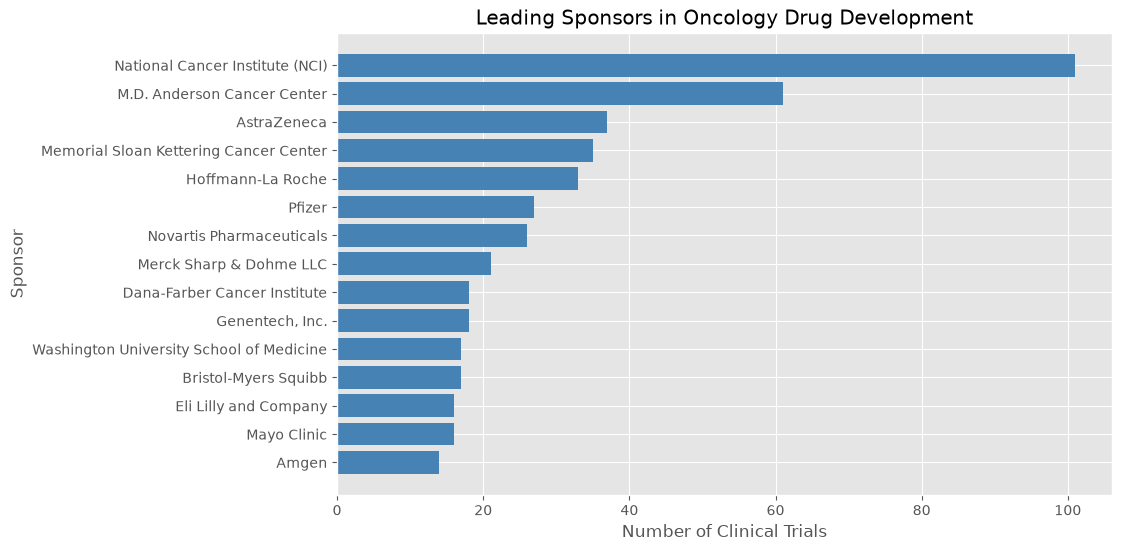

In [221]:
plt.figure(figsize=(10,6))

plt.barh(
    sponsor_counts.index[::-1],
    sponsor_counts.values[::-1], # invertimos y el 1º va arriba
    color="steelblue"
)

plt.xlabel("Number of Clinical Trials")
plt.ylabel("Sponsor")

plt.title(
    "Leading Sponsors in Oncology Drug Development"
)
plt.savefig("../figures/leading_sponsors.png", dpi=300)

plt.show()

In [155]:
df_drugs["sponsor_type"].value_counts()

sponsor_type
OTHER        1002
INDUSTRY      731
NIH           108
NETWORK        56
OTHER_GOV      16
FED             4
INDIV           1
Name: count, dtype: int64

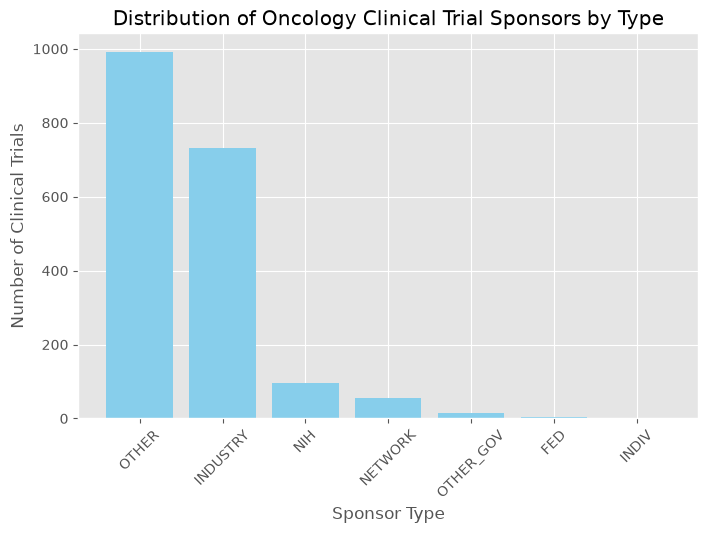

In [222]:
sponsor_type_counts = (
    df_drugs["sponsor_type"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    sponsor_type_counts.index,
    sponsor_type_counts.values,
    color="skyblue"
)

plt.xlabel("Sponsor Type")
plt.ylabel("Number of Clinical Trials")

plt.title(
    "Distribution of Oncology Clinical Trial Sponsors by Type"
)

plt.xticks(rotation=45)
plt.savefig("../figures/sponsor_type.png", dpi=300)
plt.show()

### Interpretation

The oncology clinical trial landscape is driven by a diverse range of sponsors.

Although pharmaceutical companies represent a major contribution to drug development, several academic institutions and public research organizations appear among the leading sponsors.

The presence of organizations such as the National Cancer Institute and specialized cancer centers highlights the collaborative nature of oncology research, where academic discoveries and industry development frequently interact.

<h2 style="color:#6BAED6;">4.4 Cancer Types and Therapeutic Areas</h2>

Cancer is a heterogeneous group of diseases with distinct biological characteristics and therapeutic challenges.

Understanding which cancer types concentrate the highest number of clinical trials provides insight into research priorities and therapeutic development trends within oncology.

In [236]:
condition_counts = (
    df_drugs["condition"]
    .value_counts()
    .head(20) 
)

condition_counts

condition
Breast Cancer                     66
Multiple Myeloma                  47
Prostate Cancer                   34
Lung Cancer                       19
Colorectal Cancer                 19
Leukemia                          19
Cancer                            19
Advanced Solid Tumors             18
Ovarian Cancer                    17
Solid Tumors                      15
Melanoma                          14
Metastatic Colorectal Cancer      12
Solid Tumor                       12
Non-Small Cell Lung Cancer        12
Neoplasms                         12
Hepatocellular Carcinoma          11
Acute Myeloid Leukemia            11
Non Small Cell Lung Cancer        11
Non-small Cell Lung Cancer        10
Carcinoma, Non-Small-Cell Lung     9
Name: count, dtype: int64

<div style="background-color:#EAF4FB; padding:10px; border-radius:5px;">
<strong> Cancer Type Standardization </strong>

ClinicalTrials.gov contains heterogeneous terminology for disease conditions. Similar cancer types may appear under different names due to variations in terminology.

To improve interpretability, cancer conditions were grouped into broader disease categories.
</div>

In [159]:
def classify_cancer(condition):

    condition = condition.lower()

    if "breast" in condition:
        return "Breast Cancer"

    elif "lung" in condition or "non-small cell" in condition or "non small cell" in condition:
        return "Lung Cancer"

    elif "colorectal" in condition or "colon" in condition:
        return "Colorectal Cancer"

    elif "prostate" in condition:
        return "Prostate Cancer"

    elif "melanoma" in condition:
        return "Melanoma"

    elif "myeloma" in condition:
        return "Multiple Myeloma"

    elif "leukemia" in condition or "leukaemia" in condition:
        return "Leukemia"

    elif "lymphoma" in condition:
        return "Lymphoma"

    elif "ovarian" in condition:
        return "Ovarian Cancer"

    elif "liver" in condition or "hepatocellular" in condition:
        return "Liver Cancer"

    elif "solid tumor" in condition or "solid tumour" in condition:
        return "Solid Tumors"

    else:
        return "Other"

In [160]:
df_drugs["cancer_category"] = (
    df_drugs["condition"]
    .apply(classify_cancer)
)

In [161]:
df_drugs["cancer_category"].value_counts()

cancer_category
Other                725
Breast Cancer        198
Lung Cancer          191
Leukemia             157
Solid Tumors         123
Lymphoma             113
Multiple Myeloma      93
Prostate Cancer       92
Colorectal Cancer     84
Melanoma              55
Ovarian Cancer        52
Liver Cancer          35
Name: count, dtype: int64

In [162]:
cancer_counts = (
    df_drugs[df_drugs["cancer_category"] != "Other"]
    ["cancer_category"]
    .value_counts()
)

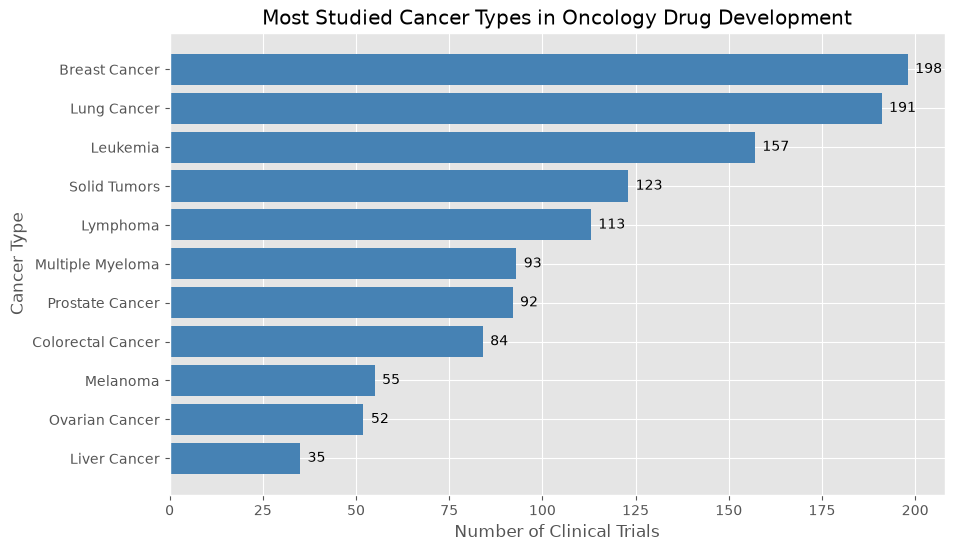

In [223]:
plt.figure(figsize=(10,6))

plt.barh(
    cancer_counts.index[::-1],
    cancer_counts.values[::-1],
    color="steelblue"
)

plt.xlabel("Number of Clinical Trials")
plt.ylabel("Cancer Type")

plt.title("Most Studied Cancer Types in Oncology Drug Development")

for index, value in enumerate(cancer_counts.values[::-1]):
    plt.text(value + 2, index, str(value), va="center")
plt.savefig("../figures/cancer_type.png", dpi=300)

plt.show()

### Interpretation

Breast cancer represents the largest therapeutic area within the analyzed oncology drug development landscape, followed by lung cancer and hematological malignancies such as leukemia, lymphoma and multiple myeloma.

The strong representation of hematological cancers reflects the rapid development of innovative therapeutic approaches, including targeted therapies, monoclonal antibodies and cellular immunotherapies.

Overall, the distribution suggests that clinical development efforts remain concentrated on high-incidence cancers while maintaining substantial investment in hematologic malignancies.

<h2 style="color:#6BAED6;">4.5 Therapeutic Landscape: Which Drugs Dominate Oncology Development?</h2>

In [164]:
df_drugs["intervention"].sample(20, random_state=42)

1464                             BGB-16673, Pirtobrutinib
2272                                            RO5185426
948     Pembrolizumab/Vibostolimab coformulation, Doce...
773       LBL-019 Injection, anti-PD-1 antibody injection
2045    Simvastatin, Sirolimus Oral Product, Everolimu...
2413                  Biospecimen Collection, Selumetinib
1723    Dalpiciclib + Aromatase Inhibitor with ctDNA-G...
726         Laser interstitial thermal therapy, Lomustine
1968                Radiotherapy, Paclitaxel, Carboplatin
1049       4-Demethyl-4-cholestryloxycarbonylpenclomedine
2944                                            CC-100004
1518    Panitumumab, Irinotecan, FOLFIRI, Pre-emptive ...
2399    Enzalutamide, Abiraterone Acetate, Prednisone,...
1956                                     Darbepoetin alfa
860     Albumin-bound paclitaxel, Carboplatin, Herceptin®
1934       Gefitinib and Metformin, Gefitinib and placebo
1397            Sorafenib (Nexavar, BAY43-9006), Eribulin
154           

<h3 style="color:cornflowerblue;">4.5A Most Frequent Investigational Drugs</h3>

In [237]:
def get_primary_drug(intervention):

    if pd.isna(intervention):
        return None

    drug = intervention.split(",")[0]

    drug = drug.split("/")[0]

    drug = drug.split("(")[0]

    return drug.strip()

<div style="background-color:#EAF4FB; padding:10px; border-radius:5px;">
<strong> Therapeutic Landscape: Most Frequently Investigated Drugs </strong>

The oncology clinical development pipeline includes a wide variety of therapeutic agents, ranging from conventional chemotherapy to targeted therapies and immunotherapies.

To simplify the analysis, the first listed drug intervention was extracted from each study and standardized to reduce inconsistencies in naming conventions.
</div>

In [240]:
df_drugs["primary_drug"] = (
    df_drugs["intervention"]
    .apply(get_primary_drug)
)

In [241]:
df_drugs["primary_drug"] = (
    df_drugs["primary_drug"]
    .str.strip()
    .str.title() 
)

In [242]:
non_drugs = [
    "Biospecimen Collection",
    "Laboratory Biomarker Analysis" 
]

df_drugs = df_drugs[
    ~df_drugs["primary_drug"].isin(non_drugs)
].copy()

In [243]:
drug_counts = (
    df_drugs["primary_drug"]
    .value_counts()
    .head(15)
)

drug_counts

primary_drug
Pembrolizumab       30
Atezolizumab        20
Cisplatin           17
Carboplatin         17
Bevacizumab         14
Paclitaxel          14
Lenalidomide        14
Cyclophosphamide    13
Rituximab           13
Nivolumab           13
Docetaxel           12
Durvalumab          11
Capecitabine        11
Filgrastim          10
Gemcitabine         10
Name: count, dtype: int64

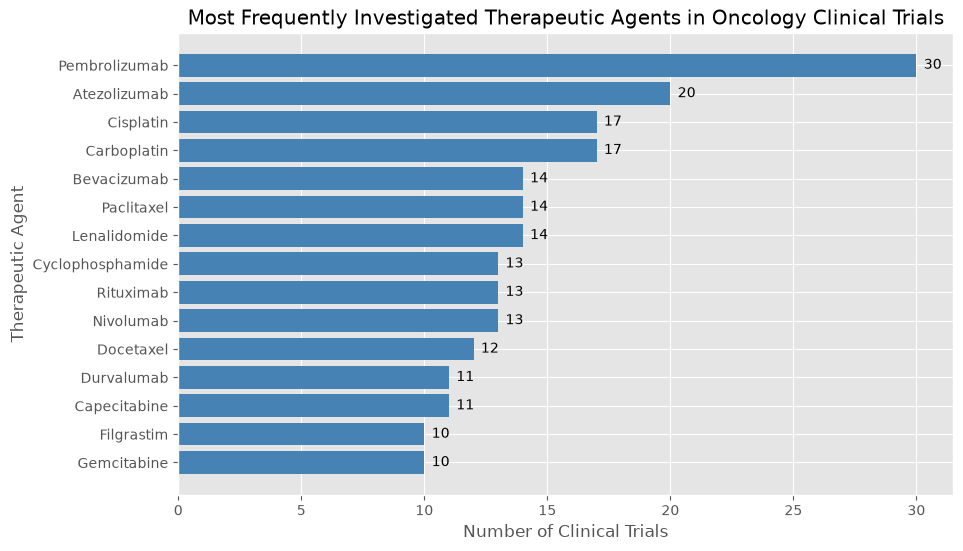

In [244]:
plt.figure(figsize=(10,6))

plt.barh(
    drug_counts.index[::-1],
    drug_counts.values[::-1],
    color="steelblue"
)

plt.xlabel("Number of Clinical Trials")
plt.ylabel("Therapeutic Agent")

plt.title("Most Frequently Investigated Therapeutic Agents in Oncology Clinical Trials")

for i, value in enumerate(drug_counts.values[::-1]):
    plt.text(value + 0.3, i, str(value), va="center")
plt.savefig("../figures/therapeutic_agents.png", dpi=300)

plt.show()

### Interpretation

Pembrolizumab emerged as the most frequently investigated therapeutic agent in the analyzed dataset, followed by atezolizumab and several conventional chemotherapeutic agents.

The prominent representation of immune checkpoint inhibitors (pembrolizumab, atezolizumab, nivolumab and durvalumab) highlights the central role of cancer immunotherapy in current clinical development. These therapies have transformed the treatment landscape across multiple tumor types and continue to be evaluated in new indications and combination strategies.

Conventional cytotoxic agents, including platinum-based chemotherapy (cisplatin and carboplatin) and taxanes (paclitaxel and docetaxel), also remain highly represented. Their continued presence reflects their role as backbone treatments in combination regimens and standard-of-care protocols.

Overall, the results illustrate the coexistence of established chemotherapies with newer immunotherapeutic and targeted approaches in the contemporary oncology pipeline.

<h3 style="color:cornflowerblue;">4.5B Therapeutic Classes</h3>

While individual therapeutic agents provide insight into the most frequently investigated drugs, grouping them into broader therapeutic classes helps identify the dominant treatment strategies currently shaping oncology drug development.

The classification below is based on the most frequently occurring therapeutic agents identified in the dataset.

| Therapeutic Class | Representative Agents | Mechanism / Clinical Role |
|-------------------|-----------------------|---------------------------|
| **Immune Checkpoint Inhibitors** | Pembrolizumab, Nivolumab, Atezolizumab, Durvalumab | Block PD-1/PD-L1 signaling to enhance anti-tumor immune responses. |
| **Chemotherapy** | Cisplatin, Carboplatin, Paclitaxel, Docetaxel, Gemcitabine, Cyclophosphamide, Capecitabine | Cytotoxic agents that remain the backbone of many oncology treatment regimens. |
| **Monoclonal Antibodies** | Bevacizumab, Rituximab | Target specific proteins involved in tumor growth or immune regulation. |
| **Targeted Therapy** | Everolimus, Olaparib, Ibrutinib, Acalabrutinib, Venetoclax, Sorafenib | Inhibit specific molecular pathways involved in cancer progression. |
| **Immunomodulatory Drugs (IMiDs)** | Lenalidomide | Enhance immune activity and are widely used in hematologic malignancies. |
| **Supportive Care** | Filgrastim | Prevents chemotherapy-induced neutropenia, allowing treatment continuation. |

### Interpretation

The therapeutic landscape identified in this analysis reflects the evolution of modern oncology. Immune checkpoint inhibitors are among the most frequently investigated agents, highlighting the major impact of cancer immunotherapy across multiple tumor types.

At the same time, conventional chemotherapy remains widely represented, illustrating its continued importance as a backbone treatment in combination regimens. Targeted therapies and monoclonal antibodies further demonstrate the shift toward precision medicine, where treatments are increasingly selected according to specific molecular characteristics of the tumor.

Overall, the analyzed pipeline suggests that contemporary oncology drug development combines established cytotoxic therapies with innovative immunotherapeutic and targeted approaches.

<h2 style="color:#6BAED6;">4.6 Therapeutic Strategies Across Cancer Types</h2>

Different cancer types often exhibit distinct therapeutic development strategies, reflecting differences in tumor biology, clinical practice and available treatment options.

To explore these patterns, the most frequently investigated therapeutic agents were identified within each major cancer category.

In [245]:
major_cancers = df_drugs[
    df_drugs["cancer_category"] != "Other" 
].copy()

In [182]:
top_drugs = (
    major_cancers
    .groupby("cancer_category")["primary_drug"]
    .agg(lambda x: x.value_counts().index[0])
)

top_drugs

cancer_category
Breast Cancer                Trastuzumab
Colorectal Cancer              Cetuximab
Leukemia                      Cytarabine
Liver Cancer                   Sorafenib
Lung Cancer                 Atezolizumab
Lymphoma                       Rituximab
Melanoma                   Pembrolizumab
Multiple Myeloma              Bortezomib
Ovarian Cancer               Carboplatin
Prostate Cancer      Abiraterone Acetate
Solid Tumors          Sorafenib Tosylate
Name: primary_drug, dtype: str

In [187]:
top3 = (
    major_cancers
    .groupby("cancer_category")["primary_drug"]
    .apply(lambda x: x.value_counts().head(3))
    
)

top3

cancer_category                             
Breast Cancer      Trastuzumab                  5
                   Pembrolizumab                4
                   Bevacizumab                  4
Colorectal Cancer  Cetuximab                    3
                   Oxaliplatin                  3
                   E7386                        2
Leukemia           Cytarabine                   5
                   Ibrutinib                    5
                   Azacitidine                  5
Liver Cancer       Sorafenib                    2
                   Durvalumab                   1
                   1.0% Ip-001 For Injection    1
Lung Cancer        Atezolizumab                 6
                   Cisplatin                    6
                   Pembrolizumab                6
Lymphoma           Rituximab                    7
                   Mosunetuzumab                4
                   Ibrutinib                    3
Melanoma           Pembrolizumab                3
     

### Interpretation

The distribution of therapeutic agents varies substantially across cancer types, reflecting disease-specific treatment strategies and evolving standards of care.

Immune checkpoint inhibitors were frequently observed across multiple solid tumors, particularly in lung cancer and melanoma, whereas hematologic malignancies showed greater representation of agents such as rituximab and lenalidomide.

These findings illustrate how therapeutic development is increasingly tailored to the biological characteristics of individual cancer types while maintaining the use of established treatments in specific clinical settings.

In [188]:
heatmap_data = pd.crosstab(
    df_drugs["cancer_category"],
    df_drugs["drug_class"]
)

heatmap_data

drug_class,Chemotherapy,Immune Checkpoint Inhibitor,Immunomodulatory Drug,Monoclonal Antibody,Other,Supportive Care,Targeted Therapy
cancer_category,,,,,,,
Breast Cancer,12,7,0,4,170,0,4
Colorectal Cancer,3,3,0,4,73,0,1
Leukemia,2,0,4,3,130,2,12
Liver Cancer,2,3,0,0,26,1,2
Lung Cancer,14,19,0,2,152,1,0
Lymphoma,2,1,1,7,92,2,6
Melanoma,1,6,0,1,45,0,1
Multiple Myeloma,3,0,6,0,81,2,1
Other,40,29,3,11,618,2,12


In [189]:
heatmap_data = heatmap_data.drop(
    index="Other",
    errors="ignore"
)

heatmap_data = heatmap_data.drop(
    columns="Other",
    errors="ignore"
)

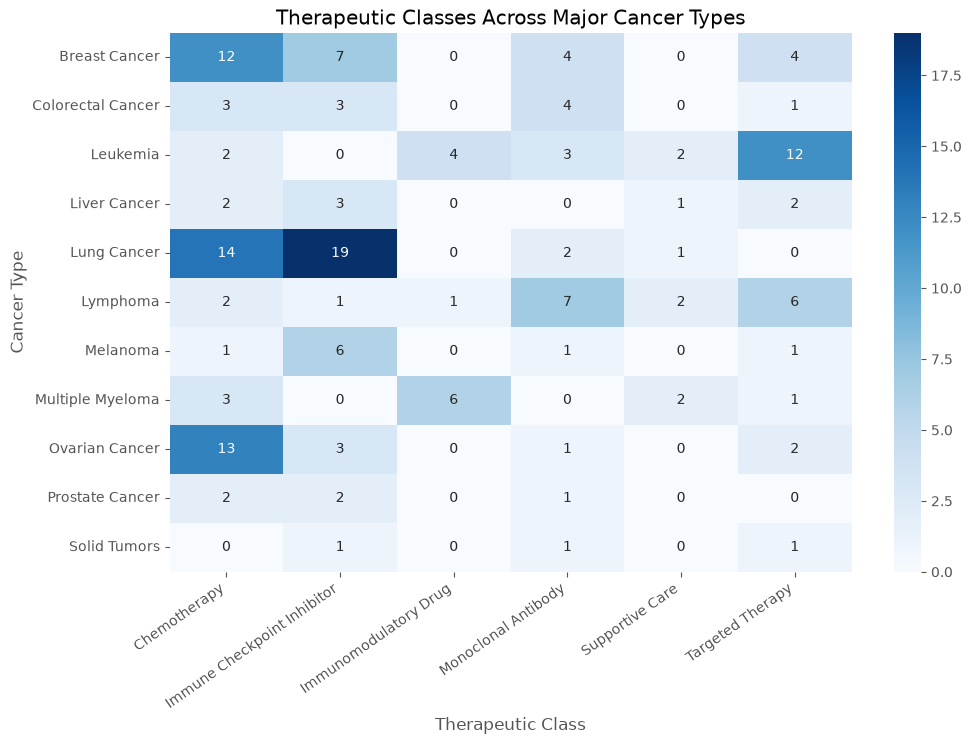

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Therapeutic Classes Across Major Cancer Types")

plt.xlabel("Therapeutic Class")
plt.ylabel("Cancer Type")
plt.xticks(rotation=35, ha="right")
plt.savefig("../figures/therapeutic_classes_heatmap.png", dpi=300)

plt.show()

### Interpretation

The heatmap reveals distinct therapeutic patterns across major cancer types, highlighting the diversity of treatment strategies in contemporary oncology.

Immune checkpoint inhibitors were predominantly associated with solid tumors such as lung cancer and melanoma, reflecting their established role in cancer immunotherapy. In contrast, hematologic malignancies displayed greater representation of disease-specific agents, including rituximab for lymphoma and bortezomib or lenalidomide for multiple myeloma.

Breast cancer showed a combination of targeted therapy (trastuzumab), immunotherapy (pembrolizumab) and anti-angiogenic therapy (bevacizumab), illustrating the increasing use of multimodal therapeutic approaches. Similarly, ovarian cancer remained strongly associated with platinum-based chemotherapy, represented by carboplatin and paclitaxel.

Overall, these findings demonstrate that therapeutic development is closely aligned with the biological characteristics and current standards of care for each cancer type, highlighting the growing importance of precision medicine in oncology.

<h1 style="color:steelblue;">5. Key Findings</h1>

This exploratory analysis of oncology clinical trials identified several important trends in the current therapeutic development landscape.

- Phase II studies represented the largest proportion of interventional oncology drug trials, highlighting the intensive evaluation of promising therapeutic candidates.

- The number of oncology clinical trials increased substantially after 2015, reflecting accelerated investment in cancer drug development.

- Research activity was driven by a combination of pharmaceutical companies, academic institutions and government organizations, illustrating the collaborative nature of oncology research.

- Breast cancer, lung cancer and hematologic malignancies accounted for a large share of the analyzed studies, demonstrating sustained research efforts across both solid and hematologic tumors.

- Immune checkpoint inhibitors emerged among the most frequently investigated therapeutic agents, while conventional chemotherapy continued to play a central role in combination treatment strategies.

- Therapeutic development varied considerably across cancer types, reflecting disease-specific biological characteristics and the growing adoption of precision medicine approaches.

<h1 style="color:steelblue;">6. Limitations & Future Work</h1>

This analysis has several limitations.

First, the study relied on publicly available data from ClinicalTrials.gov, which may contain heterogeneous terminology and incomplete metadata. Drug names and disease conditions required manual standardization to improve consistency.

Second, only the first listed therapeutic agent was extracted for part of the analysis, which may not fully represent combination therapies commonly used in oncology.

Future work could include:

- Automatic normalization of drug names using biomedical ontologies.
- Classification of therapies based on mechanism of action.
- Network analysis of drug combinations.
- Analysis of sponsors by therapeutic area.
- Integration with FDA drug approval data.
- Interactive dashboards using Plotly or Tableau.